This notebook produces figures associated with single chamber verification and model output.

In [19]:
import numpy as np
import matplotlib.pyplot as plt

import cnetwork

In [20]:
# Set reference density of melt
rhoref = 2500

# Constant viscosity assumption
mu0 = 1e6
# Effective hydraulic radius
r_hydr = 5

# Fix total volume
total_vol = (4/3)*np.pi*1000.0**3
# Fix mass injection
mass_inj = total_vol * rhoref * 0.001

# Network parameters
N_chamber = 1
x_scale = 10000.0
y_scale = 0.0
z_scale = 10000.0 # Depth

In [21]:
# Random distribution
np.random.seed(0)

# Set limits of characteristic size of chamber
R_min = 100
R_max = 1000
# Uniformly randomly distribution volume
V_min = (4/3)*np.pi*R_min**3
V_max = (4/3)*np.pi*R_max**3

# List generation of chamber characteristics
x_nodes = x_scale * np.random.rand(N_chamber)
y_nodes = y_scale * np.random.rand(N_chamber)
z_nodes = z_scale * np.random.rand(N_chamber)
V_nodes = V_min + (V_max - V_min) * np.random.rand(N_chamber)

list_nodes = [cnetwork.MagmaChamber(x=x, y=y, z=z,
  p_setting=None, vref=1.0/rhoref,
  T_setting=1000+273.15, V_setting=V)
  for (x,y,z,V) in zip(x_nodes, y_nodes, z_nodes, V_nodes)]

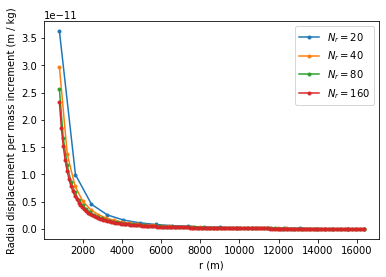

In [22]:
Nr_range = [20, 40, 80, 160]

material_properties = cnetwork.default_props()
numerics = cnetwork.default_numerics()

for Nr in Nr_range:

  # Set up system
  numerics["Nr"] = Nr

  global_sys = cnetwork.GlobalSystemThreshold(list_nodes,
    **material_properties,
    **numerics,
    dpdx_crit=1e3, dpdx_threshold_scale=1e1, max_edge_dist=np.inf)

  # Extraction
  node = global_sys.nodes[0]
  q0 = global_sys.q0
  # Column mapping mass to displacement
  H_col = np.array(node.H[:,2*global_sys.Nr].todense()).ravel()
  k = node.k.ravel()
  plt.plot(node.r_mesh, H_col + 0*k, '.-', label=f"$N_r = {Nr:d}$")
  H_col.flatten()
 
plt.xlabel("r (m)")
plt.ylabel("Radial displacement per mass increment (m / kg)")
plt.legend()

Linear displacement $u$ is given by
$$
u = Hq + k,
$$
with Jacobian
$$
\frac{\partial u}{\partial q} = H
$$
where the $j$-th column of $u$ gives the dependence of $u$ on $q_j$.

For the pure elastic problem, the exact solution for the exterior of a spherical inclusion of radius $R_0$ is
$$
u = U R_0^2 r^{-2},
$$
where
$$
U = \frac{R_0}{3} \left( \frac{m}{m_0} - 1 \right) \frac{K_\mathrm{f}}{K_\mathrm{f} + (4G / 3)}
$$
is dependent on the injected mass $\Delta m / m_0 = m/m_0 - 1$ and the fluid bulk modulus $K_\mathrm{f}$.

Note that the interior elastic problem is in a uniform volumetric stress/strain state, with no deviatoric stress/strain.

In the limit of a highly compressible fluid, $K_\mathrm{f} = \varepsilon \downarrow 0$, and
$$
U \approx \frac{R_0}{4G} \left( \frac{m}{m_0} - 1 \right) K_\mathrm{f},
$$
which can be compared to the displacement solution using a pressure boundary condition $p (r= R_0) = p_0$. In the latter case, the characteristic displacement is
$$
U_{p_0} = \frac{R_0}{4G} p_0;
$$
the relative pressure $p_0$ can be identified with the quantity $K_\mathrm{f} \Delta m / m_0 \approx K_\mathrm{f} \Delta V / V_0$.

In the following, we compare the dependence of the boundary displacement on mass. That is, we compare $\partial u / \partial m$ at $r = R_0$ and $t = 0$ with the analytic formula
$$
\frac{\partial u}{\partial m} = \frac{R_0}{3 m_0} \frac{K_\mathrm{f}}{K_\mathrm{f} + (4G / 3)},
$$
where $G$ is the crustal shear modulus.

Comparison of dependence of wall displacement u(r = R) on mass:


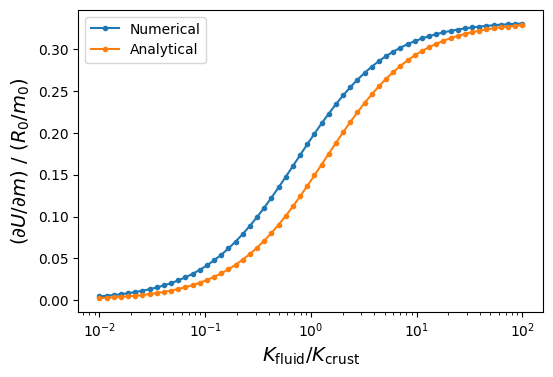

In [35]:
# Get/set properties
K_crust = material_properties["K_crust_default"]
G_crust = material_properties["G_crust_default"]
numerics["Nr"] = 50

# Set range of K_fluid to sweep over
K_f_range = np.geomspace(1e-2, 1e2, 60) * K_crust
dRdm_range = np.zeros_like(K_f_range, dtype=float)

for i, K_f in enumerate(K_f_range):
  material_properties["K_f_default"] = K_f
  global_sys = cnetwork.GlobalSystemThreshold(list_nodes,
    **material_properties,
    **numerics,
    dpdx_crit=1e3, dpdx_threshold_scale=1e1, max_edge_dist=np.inf)
  
  # Extract H_col == du/d
  node = global_sys.nodes[0]
  q0 = global_sys.q0
  # Column mapping mass to displacement
  H_col = np.array(node.H[:,2*global_sys.Nr].todense()).ravel()
  k = node.k.ravel()
  dRdm_range[i] = H_col.flatten()[0]

def dUdm_analytic(K_f):
  return node.R0 / (3 * node.m0) * K_f / (K_f + (4.0/3.0) * G_crust)

plt.figure(figsize=(6,4) , dpi=100)
plt.semilogx(K_f_range / K_crust, dRdm_range / (node.R0 / node.m0), '.-', label="Numerical")
plt.semilogx(K_f_range / K_crust, dUdm_analytic(K_f_range) / (node.R0 / node.m0), '.-', label="Analytical")
plt.xlabel("$K_\mathrm{fluid} / K_\mathrm{crust}$", fontsize=14)
plt.ylabel("$(\partial U / \partial m) ~/~ (R_0 / m_0)$", fontsize=14)
plt.legend()
print("Comparison of dependence of wall displacement u(r = R) on mass:")

K_f / K = 1e+02


C:\Users\Fredric\AppData\Local\Temp\ipykernel_39948\1334000743.py:42: RuntimeWarning: divide by zero encountered in true_divide
  lambda N: (node.r_mesh[-1] - node.r_mesh[0]) / N))


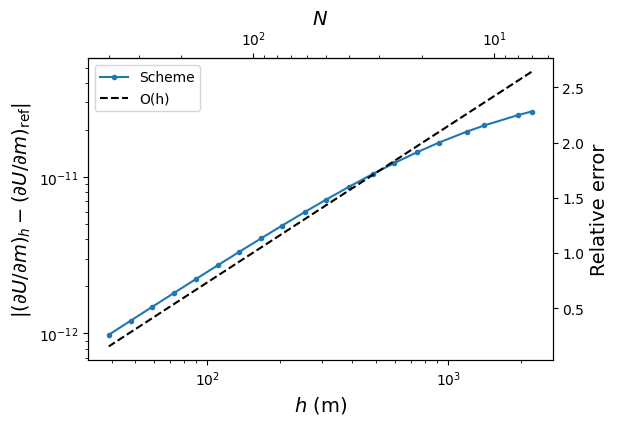

In [ ]:
''' Grid convergence at K_f == K '''

Nr_range = np.geomspace(8, 400, 20).astype(int)
dr_range = np.zeros_like(Nr_range, dtype=float)
dRdm_range2 = np.zeros_like(Nr_range, dtype=float)
material_properties["K_f_default"] = K_crust

for i, Nr in enumerate(Nr_range):
  numerics["Nr"] = Nr
  global_sys = cnetwork.GlobalSystemThreshold(list_nodes,
    **material_properties,
    **numerics,
    dpdx_crit=1e3, dpdx_threshold_scale=1e1, max_edge_dist=np.inf)
  
  # Extraction
  node = global_sys.nodes[0]
  q0 = global_sys.q0
  # Column mapping mass to displacement
  H_col = np.array(node.H[:,2*global_sys.Nr].todense()).ravel()
  k = node.k.ravel()
  dRdm_range2[i] = H_col.flatten()[0]
  dr_range[i] = node.dx

ref_soln = dUdm_analytic(K_crust)

plt.figure(figsize=(6,4) , dpi=100)
plt.loglog(dr_range, np.abs(dRdm_range2 - ref_soln), '.-')
plt.loglog(dr_range, dr_range / dr_range[0] * dRdm_range2[0], 'k--')
plt.legend(["Scheme", "O(h)"])
plt.xlabel("$h$ (m)", fontsize=14)
plt.ylabel("$|(\partial U / \partial m)_h - (\partial U / \partial m)_\mathrm{ref}|$", fontsize=14)

ax1 = plt.gca()
ax2x = ax1.twinx()
ymin, ymax = ax1.get_ylim()
ax2x.set_ylim(ymin / ref_soln, ymax / ref_soln)
ax2x.set_ylabel('Relative error', fontsize=14)

ax2y = ax1.secondary_xaxis('top', functions=(
  lambda h: (node.r_mesh[-1] - node.r_mesh[0]) / h,
  lambda N: (node.r_mesh[-1] - node.r_mesh[0]) / N))
ax2y.set_xlabel('$N$', fontsize=14)

print(f"K_f / K = {K_f/K_crust:.2}")